<a href="https://colab.research.google.com/github/jackieuxui/Extract-Structure-Data-from-Mortgage-PDFs/blob/main/Jackie_Carlos_Extract_%26_Structure_Data_from_Mortgage_PDFs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extract & Structure Data from Mortgage PDFs

## Step 1: Setup Environment

In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 51.6 MB/s eta 0:00:00


Upload Lender Fees Worksheet

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving LenderFeesWorksheetNew.pdf to LenderFeesWorksheetNew.pdf


In [ ]:
import os
print(os.listdir())

['.config', 'LenderFeesWorksheetNew.pdf', 'sample_data']


## Step 2: Inspecting the PDF

In [ ]:
import fitz

In [ ]:
# Load the PDF
doc = fitz.open("LenderFeesWorksheetNew.pdf")


# Print the number of pages
print(f"Total Pages: {doc.page_count}")


# Print metadata
print("PDF Metadata:")

doc.metadata


Total Pages: 1
PDF Metadata:


{'format': 'PDF 1.3',
 'title': 'POINT Document',
 'author': '',
 'subject': '',
 'keywords': '',
 'creator': '',
 'producer': 'Amyuni PDF Converter version 4.5.2.3',
 'creationDate': "D:20151001155359-07'00'",
 'modDate': '',
 'trapped': '',
 'encryption': None}

## Step 3: Extracting Text from a PDF

### Extracting Text Block with Bounding Box Positions

In [ ]:

structured_output = []

for page in doc:
    blocks = page.get_text("blocks", sort = True)

    for block in blocks:
        x0, y0, x1, y1, text, block_no, block_type = block

        clean_text = text.strip()

        if clean_text:
            structured_output.append({
                "text": clean_text,
                "bbox": [x0, y0, x1, y1]
            })

structured_output

[{'text': 'Your actual rate, payment, and cost could be higher. Get an official Loan Estimate before choosing a loan.',
  'bbox': [36.0, 26.097490310668945, 587.3409423828125, 38.3197021484375]},
 {'text': 'FEES WORKSHEET',
  'bbox': [237.60000610351562,
   42.08164596557617,
   368.0303649902344,
   57.68054962158203]},
 {'text': 'Fee Details and Summary',
  'bbox': [230.39999389648438,
   58.18072509765625,
   376.87939453125,
   71.53446197509766]},
 {'text': 'Applicants:\nApplication No:\nDate Prepared:\nLoan Program:\nPrepared By:',
  'bbox': [39.599998474121094,
   78.64180755615234,
   463.07476806640625,
   107.48875427246094]},
 {'text': 'John Q. Smith / Mary A. Smith\nsamplesmith\n10/05/2015\n30 YEAR FIXED -Purchase\nXYZ Lender',
  'bbox': [100.80000305175781,
   78.44451904296875,
   571.6966552734375,
   107.53496551513672]},
 {'text': 'THIS IS NOT A GOOD FAITH ESTIMATE (GFE). This "Fees Worksheet" is provided for informational purposes ONLY, to assist\nyou in determining a

block number 0
(36.0, 26.097490310668945, 587.3409423828125, 38.3197021484375, 'Your actual rate, payment, and cost could be higher. Get an official Loan Estimate before choosing a loan.\n', 0, 0) 

block number 12
(237.60000610351562, 42.08164596557617, 368.0303649902344, 57.68054962158203, 'FEES WORKSHEET\n', 12, 0) 

block number 1
(230.39999389648438, 58.18072509765625, 376.87939453125, 71.53446197509766, 'Fee Details and Summary\n', 1, 0) 

block number 2
(39.599998474121094, 78.64180755615234, 463.07476806640625, 107.48875427246094, 'Applicants:\nApplication No:\nDate Prepared:\nLoan Program:\nPrepared By:\n', 2, 0) 

block number 13
(100.80000305175781, 78.44451904296875, 571.6966552734375, 107.53496551513672, 'John Q. Smith / Mary A. Smith\nsamplesmith\n10/05/2015\n30 YEAR FIXED -Purchase\nXYZ Lender\n', 13, 0) 

block number 3
(39.599998474121094, 119.17501068115234, 572.3463134765625, 147.94798278808594, 'THIS IS NOT A GOOD FAITH ESTIMATE (GFE). This "Fees Worksheet" is provi

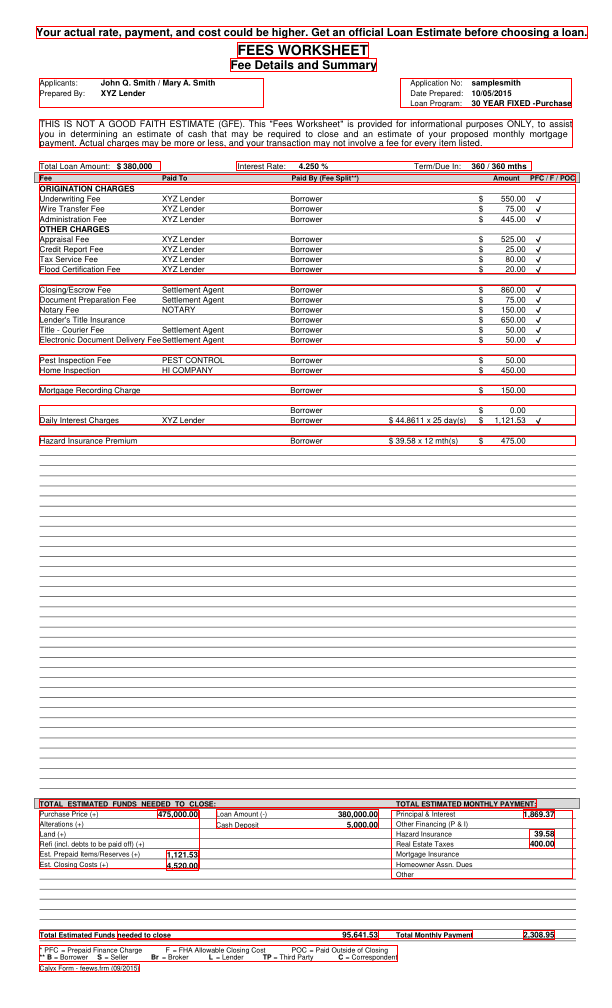

[{'text': 'Your actual rate, payment, and cost could be higher. Get an official Loan Estimate before choosing a loan.',
  'bbox': [36.0, 26.097490310668945, 587.3409423828125, 38.3197021484375]},
 {'text': 'FEES WORKSHEET',
  'bbox': [237.60000610351562,
   42.08164596557617,
   368.0303649902344,
   57.68054962158203]},
 {'text': 'Fee Details and Summary',
  'bbox': [230.39999389648438,
   58.18072509765625,
   376.87939453125,
   71.53446197509766]},
 {'text': 'Applicants:\nApplication No:\nDate Prepared:\nLoan Program:\nPrepared By:',
  'bbox': [39.599998474121094,
   78.64180755615234,
   263.07476806640625,
   107.48875427246094]},
 {'text': 'John Q. Smith / Mary A. Smith\nsamplesmith\n10/05/2015\n30 YEAR FIXED -Purchase\nXYZ Lender',
  'bbox': [400.8000030517578,
   78.44451904296875,
   571.6966552734375,
   107.53496551513672]},
 {'text': 'THIS IS NOT A GOOD FAITH ESTIMATE (GFE). This "Fees Worksheet" is provided for informational purposes ONLY, to assist\nyou in determining an

In [ ]:
import fitz
from PIL import Image, ImageDraw
from IPython.display import display

# Open PDF
doc = fitz.open("LenderFeesWorksheetNew.pdf")

# Select first page
page = doc[0]

# Convert PDF page to image
pix = page.get_pixmap()

# Save temporary image
pix.save("page_image.png")

# Open image with PIL
img = Image.open("page_image.png")

# Create drawing object
draw = ImageDraw.Draw(img)

# Extract text blocks
blocks = page.get_text("blocks", sort= True)

structured_output = []

for block in blocks:
    x0, y0, x1, y1, text, block_no, block_type = block

    clean_text = text.strip()

    if clean_text:


        # Extend blocks 8 BEFORE drawing
        if block_no == 2:
            x1 -= 200
        # Extend blocks 4 BEFORE drawing (Total Amount)
        if block_no == 4:
            x1 -= 300

        # Extend blocks 8 BEFORE drawing
        if block_no == 8:
            x1 += 55
        # Extend blocks 9 BEFORE drawing
        if block_no == 9:
            x0 += 175
            x1 += 100
        # Extend blocks 13 BEFORE drawing
        if block_no == 13:
            x0 += 300
        # Extend blocks 14 BEFORE drawing (Interest Rate and Term Due Date)
        if block_no == 14:
            x0 += 120
            x1 += 5


        # Extend blocks 22-27 BEFORE drawing
        if 22 <= block_no <= 27:
            x1 += 50

        # Store structured output
        structured_output.append({
            "text": clean_text,
            "bbox": [x0, y0, x1, y1],

        })

        # Draw ONLY ONCE
        draw.rectangle(
            [x0, y0, x1, y1],
            outline="red",
            width=1
        )
for block_item in blocks: # Renamed 'block' to 'block_item' to avoid confusion with the unpacked 'block' from the first loop
  # The block_no is at index 5 in the tuple
  print('block number',block_item[5])
  print(block_item,'\n')

# Display image with bounding boxes
display(img)

# Optional: print extracted text + bbox
structured_output

In [ ]:
output_image_path = "clean_img_with_bboxes.png"
img.save(output_image_path)
print(f"Image with bounding boxes saved to: {output_image_path}")

Image with bounding boxes saved to: clean_img_with_bboxes.png
